<a href="https://colab.research.google.com/github/Bigenlight/Manipulator_study/blob/main/3_binary_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

4-1강
4-2강 <- 파라미터 튜닝

# Binary Classifiaction (이진분류) + 하이퍼파라미터 튜닝 실습

https://youtu.be/kMU-JlvquS0?si=_RHB36jVpD3UIqbO

+ ctrl + F9으로 한번에 실행


In [503]:
import torch

## STEP 1. 데이터 모으기

- 아래는 데이터를 생성하는 과정

In [504]:
# # case 1
# N=20 # 총 데이터 20개

# # 데이터 생성
# random0=torch.randn(int(N/2),1) # 데이터 10개는 0 근처로 가우시안 분포
# random5=torch.randn(int(N/2),1)+5 # 나머지 10개는 5 근처로 정규분포

# # 데이터 2개로 분류해서 넣기
# class1_data=torch.hstack([random0,random5])
# class2_data=torch.hstack([random5,random0])

# # 정답지, 0과 1로 라벨 작성
# class1_label=torch.ones(int(N/2),1)
# class2_label=torch.zeros(int(N/2),1)

# X=torch.vstack([class1_data,class2_data]) # 클래스1,2 데이터들을 쌓음
# y=torch.vstack([class1_label,class2_label]) # 클래스1,2의 라벨들을 쌓음

# case 2

N=100
radius1=0.3+0.05*torch.randn(int(N/2),1)
radius2=1+0.01*torch.randn(int(N/2),1)
theta1=2*torch.pi*torch.rand(int(N/2),1)-torch.pi
theta2=2*torch.pi*torch.rand(int(N/2),1)-torch.pi
class1_data=torch.hstack([radius1*torch.cos(theta1), radius1*torch.sin(theta1)])
class2_data=torch.hstack([radius2*torch.cos(theta2), radius2*torch.sin(theta2)])
class1_label=torch.ones(int(N/2),1)
class2_label=torch.zeros(int(N/2),1)
X=torch.vstack([class1_data,class2_data])
y=torch.vstack([class1_label,class2_label])

print(X)
print(y)

tensor([[-0.1391,  0.1443],
        [ 0.2702,  0.2203],
        [-0.1666, -0.2964],
        [ 0.3197,  0.1101],
        [ 0.1668,  0.2768],
        [-0.3272,  0.0541],
        [-0.2570, -0.0310],
        [-0.0017, -0.3266],
        [ 0.2200,  0.0937],
        [ 0.1675, -0.1880],
        [ 0.0900, -0.3328],
        [-0.2034,  0.1225],
        [-0.3235,  0.0022],
        [ 0.1374, -0.2387],
        [ 0.3130, -0.0928],
        [ 0.2060, -0.1114],
        [ 0.3487, -0.1670],
        [-0.2884, -0.1547],
        [-0.2984,  0.0499],
        [-0.2914,  0.2198],
        [ 0.0874,  0.3024],
        [ 0.0333, -0.2858],
        [ 0.1346, -0.2827],
        [-0.1008, -0.2914],
        [ 0.0329, -0.2936],
        [ 0.2342, -0.1391],
        [ 0.1373,  0.0929],
        [-0.2753, -0.2515],
        [-0.2623,  0.1288],
        [-0.3060, -0.1984],
        [-0.0568, -0.3182],
        [-0.0775,  0.2872],
        [ 0.3005,  0.0566],
        [-0.2980,  0.1604],
        [ 0.1122, -0.2811],
        [-0.1846, -0

- 아래 데이터 라벨, 즉 정답지들이 얼마나 분포 됐는지 시각화. 0이 파란색, 1일 빨간색 라벨

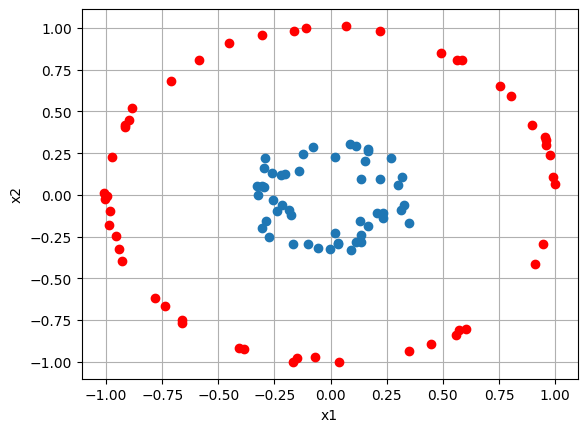

In [505]:
import matplotlib.pyplot as plt
plt.plot(class1_data[:,0],class1_data[:,1],'o') # 클래스 1 데이터들
plt.plot(class2_data[:,0],class2_data[:,1],'ro') # 클래스 2 데이터들
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

과연 파란점과 붉은점들을 잘 구별할 수 있을까?

## STEP 2. 모델 만들기

- 파라미터를 다르게 하며 여러 케이스로 테스트 가능


In [506]:
from torch import nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        # CASE 1
        # # case 1, plain
        # self.linear = nn.Sequential(nn.Linear(2, 1000), # 10,100,1000,10000 으로 바꿔보면서서 확인
        #                             nn.Sigmoid(),
        #                             nn.Linear(1000, 1), # node가 많을수록 좋게 나옴
        #                             nn.Sigmoid())

        # # case 1, very simple
        # self.linear = nn.Sequential(nn.Linear(2, 1), # 아주 simple 한 것도 오히려 갠춘
        #                             nn.Sigmoid())

        # # case 1, deep
        # self.linear = nn.Sequential(nn.Linear(2, 100), # deep 하면 오래 걸림 (adam으로 바꾸면 해결 (작은 gradient면 분모가 작아져서 쭉쭉 나아감)) vanishing gradient랑 좀 다른 문제인 것 같다
        #                             nn.Sigmoid(),
        #                             nn.Linear(100, 100),
        #                             nn.Sigmoid(),
        #                             nn.Linear(100, 100),
        #                             nn.Sigmoid(),
        #                             nn.Linear(100, 1),
        #                             nn.Sigmoid())


        # CASE 2

        # # case 2, plain
        # self.linear = nn.Sequential(nn.Linear(2, 100),
        #                             nn.Sigmoid(),
        #                             nn.Linear(100, 1),
        #                             nn.Sigmoid())

        # # case 2, very simple
        # self.linear = nn.Sequential(nn.Linear(2, 1), # 선형 분류만 가능해서 불가
        #                             nn.Sigmoid()) # 안됨

        # # case 2, deep
        # self.linear = nn.Sequential(*[nn.Linear(2, 100), # LR을 줄이니까 수렴
        #                             nn.Sigmoid(),
        #                             nn.Linear(100, 100),
        #                             nn.Sigmoid(),
        #                             nn.Linear(100, 100),
        #                             nn.Sigmoid(),
        #                             nn.Linear(100, 1),
        #                             nn.Sigmoid()])

        # # case 2, very deep
        # self.linear = nn.Sequential(nn.Linear(2, 100),
        #                             nn.Sigmoid(),
        #                             *[i for _ in range(10) for i in [nn.Linear(100, 100), nn.Sigmoid()]],
        #                             nn.Linear(100, 1),
        #                             nn.Sigmoid())

        # case 2, very deep relu
        self.linear = nn.Sequential(nn.Linear(2, 100),
                                    nn.ReLU(),
                                    *[i for _ in range(10) for i in [nn.Linear(100, 100), nn.ReLU()]],
                                    nn.Linear(100, 1),
                                    nn.Sigmoid())

    def forward(self, x):
        x = self.linear(x)
        return x

case1 실험:

- 노드가 많을수록 양탄자 경사가 완만하게 내려감. Loss도 덜 내려가고.

- 이 문제의 경우 놀랍게도 뉴런이 2개 밖에 안되도 잘 됨. 꼭 많아야 좋은 것은 아님.

- 층이 깊어져도 항상 좋은게 아님. 층을 늘리면 초반에 학습하는데 오래 걸림. 그래서 epoch를(100을 실패함) 늘려주거나 ADAM을 써야함.

case2 실험:

- 하지만 case2의 데이터 분포의 경우 뉴런이 2개로 충분하지 않음. 어떻게 해도 안됨.

  - 왜냐하면 뉴런 2개를 가지고 어떻게 해도 결국 만들 수 있는 것은 직선의 방정식 뿐임. 결국 `w1x1 + w2x2 + c =0`가 한계, 그리고 이는 결국 일차 방정식임.

  - case2 분포는 선형으로 구별이 안됨.

  - 조금 깊어야지 가능. 이 경우 중간에 시그모이드 하나, 즉 은닉 층이 한층만 되는 plain도 되긴함.

- 너무 깊으면 근데 또 안됨.

  - 모델이 학습할 능력이 있어도 안됨.

  - 왜냐하면 시그모이드를 사용했을 때 gradient vanishing 문제가 일어나기 때문임!

  - 그래서 시그모이드들을 ReLU로 바꾸면 됨!! 뒤로 Loss 전달 가능.

    - 물론 출력층은 그래도 시그모이드를 써야함.



In [507]:
# nn.Sequential(*[nn.Sequential(nn.Linear(100,100), nn.Sigmoid()) for _ in range(10)])
# nn.Sequential(*[nn.Linear(100,100) if i % 2 == 0 else nn.Sigmoid() for i in range(20)])
# nn.Sequential(*[i for _ in range(10) for i in [nn.Linear(100,100), nn.Sigmoid()]])

- 모델 내부 구성 출력

In [508]:
model = MLP()
print(model)

# 모델 한번 통과해보기, 당연히 이상한 값을 출력함, 아직 학습한게 없음
model.eval()
with torch.no_grad():
    print(model(torch.randn(5,2))) # 2개 값으로 이루어진 좌표값 (x1,x2) 데이터 5개를 입력함

MLP(
  (linear): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): ReLU()
    (8): Linear(in_features=100, out_features=100, bias=True)
    (9): ReLU()
    (10): Linear(in_features=100, out_features=100, bias=True)
    (11): ReLU()
    (12): Linear(in_features=100, out_features=100, bias=True)
    (13): ReLU()
    (14): Linear(in_features=100, out_features=100, bias=True)
    (15): ReLU()
    (16): Linear(in_features=100, out_features=100, bias=True)
    (17): ReLU()
    (18): Linear(in_features=100, out_features=100, bias=True)
    (19): ReLU()
    (20): Linear(in_features=100, out_features=100, bias=True)
    (21): ReLU()
    (22): Linear(in_features=100, out_features=1, bias=True)
    (23): Sigmoid()
  )
)
tensor([[0.4941]

## STEP 3. 모델 학습시키기

- Learning rate, epoch, 옵티마이저 바꿔가면서 연습해볼 것

In [509]:
from torch import optim
# !pip install torchviz # 내 필기용
# from torchviz import make_dot # 내 필기용

# 파라미터 세팅 +
# LR = 1e-1 # case 1
# LR = 1e-2 # case 2, plain 에서 노드 천 개, deep
LR = 1e-4 # case 2, very deep relu
# EPOCH = 100 # case 1
EPOCH = 500 # case 2, plain 에서 노드 천 개, deep, very deep relu

# 옵티마이저 ++
# optimizer = optim.SGD(model.parameters(), lr=LR)
optimizer = optim.Adam(model.parameters(), lr=LR) # case 1, deep
# optimizer = optim.Adam(model.parameters(), lr=LR, eps=0, betas=(0.9, 0.99)) # 내 필기용
# optimizer = optim.Adam(model.parameters(), lr=LR, eps=1e-12, betas=(0.1, 0.1)) # 내 필기용

# 손실함수
# criterion은 기준, 척도라는 뜻임. 손실함수를 담는 변수명으로 관용적으로 쓰임 +
criterion = nn.BCELoss() # criterion은 고유명칭이 아닌 사람이 지정함.

loss_history=[]
grad_history=[] # 내 필기용
update_size_history=[] # 내 필기용

model.train() # train mode로 전환 +

for ep in range(EPOCH):
    # inference ++
    y_hat = model(X) # X에 좌표 값들이 다 들어감

    # loss ++
    loss = criterion(y_hat, y)

    # prev weights # 내 필기용
    # prev=model.linear[0].weight.detach().clone() # 내 필기용

    # update ++
    optimizer.zero_grad() # gradient 누적을 막기 위한 초기화
    loss.backward() # backpropagation
    optimizer.step() # weight update

    # update amount # 내 필기용
    # grad_history += [ torch.sum(torch.abs( model.linear[0].weight.grad )).item() ] # 내 필기용
    # update_size_history += [ torch.sum(torch.abs( model.linear[0].weight.detach() - prev)).item() ] # 내 필기용
    # print loss
    loss_history += [loss.item()]
    print(f"Epoch: {ep+1}, train loss: {loss.item():.4f}")
    print("-"*20)

Epoch: 1, train loss: 0.6932
--------------------
Epoch: 2, train loss: 0.6932
--------------------
Epoch: 3, train loss: 0.6932
--------------------
Epoch: 4, train loss: 0.6932
--------------------
Epoch: 5, train loss: 0.6932
--------------------
Epoch: 6, train loss: 0.6932
--------------------
Epoch: 7, train loss: 0.6932
--------------------
Epoch: 8, train loss: 0.6932
--------------------
Epoch: 9, train loss: 0.6932
--------------------
Epoch: 10, train loss: 0.6932
--------------------
Epoch: 11, train loss: 0.6931
--------------------
Epoch: 12, train loss: 0.6931
--------------------
Epoch: 13, train loss: 0.6931
--------------------
Epoch: 14, train loss: 0.6931
--------------------
Epoch: 15, train loss: 0.6931
--------------------
Epoch: 16, train loss: 0.6931
--------------------
Epoch: 17, train loss: 0.6931
--------------------
Epoch: 18, train loss: 0.6931
--------------------
Epoch: 19, train loss: 0.6931
--------------------
Epoch: 20, train loss: 0.6931
----------

- 실제 BCE 수식과 cirterion에 집어넣은 nn.BCELoss 매서드가 잘 맞는지 체크

In [510]:
print(criterion(y_hat,y))
print(torch.sum(-torch.log( y_hat**y  *  (1-y_hat)**(1-y))) /N )
print(criterion(torch.tensor([0.]),torch.tensor([1.]))) # 100 이 최대다..!

tensor(1.1198e-06, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(1.1206e-06, grad_fn=<DivBackward0>)
tensor(100.)


Text(0, 0.5, 'Loss')

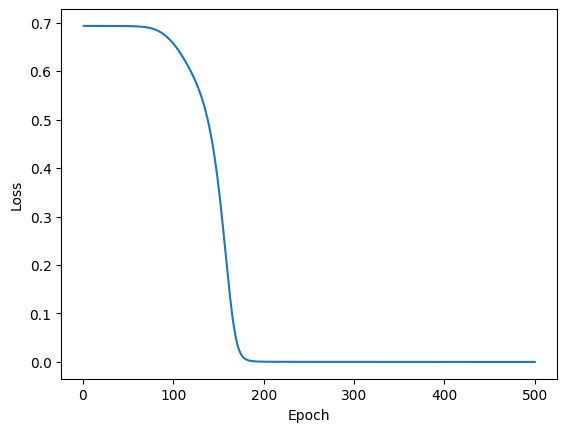

In [511]:
# plt.figure(figsize=(6,9)) # 내 필기용
# plt.subplot(2,1,1) # 내 필기용
plt.plot(range(1,EPOCH+1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
# plt.subplot(2,1,2) # 내 필기용
# plt.plot(range(1,EPOCH+1), grad_history) # 내 필기용
# plt.xlabel("Epoch") # 내 필기용
# plt.ylabel("grad size") # 내 필기용

- 참고로 BCE에서 정답이 1인데 출력이 0이면 -log라 Loss가 무한대로 가게 된다. 하지만 torch에서 log로 보낼 수 있는 **최댓값이 100**이다. 제작자들이 막아놨다. 그 이상을 가지 않는다.

## STEP 4. 모델 테스트하기

- 모든 값에 대한 예측값을 다 찍어서 3D로 만들기.

Text(0.5, 0.5, 'x2')

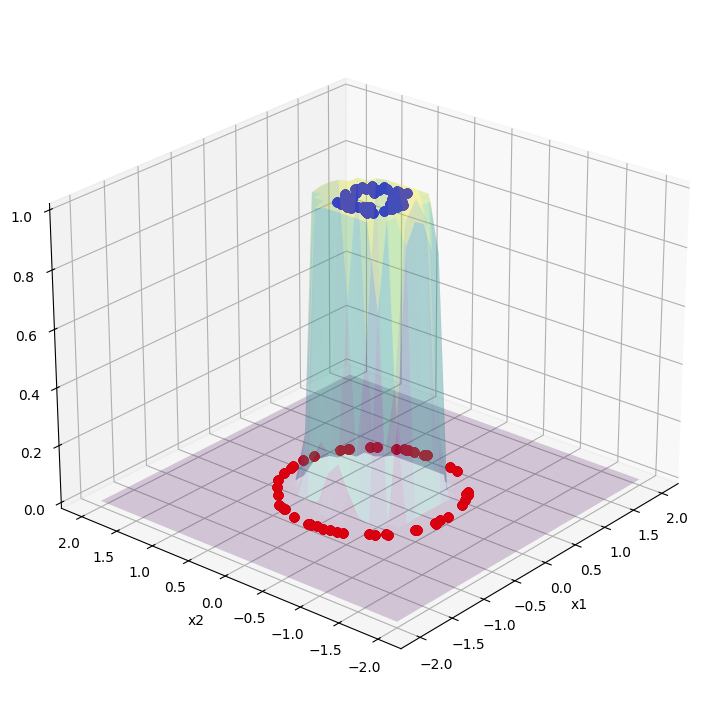

In [512]:
# from matplotlib.colors import LightSource # 내 필기용

# 30x30x2의 데이터를 만들어서 다 집어넣기
# x1_test=torch.linspace(-10,10,30) # case 1
# x2_test=torch.linspace(-10,10,30) # case 1
x1_test=torch.linspace(-2,2,30) # case 2
x2_test=torch.linspace(-2,2,30) # case 2
X1_test, X2_test=torch.meshgrid(x1_test,x2_test)
X_test=torch.cat([X1_test.unsqueeze(dim=2), X2_test.unsqueeze(dim=2)], dim=2)

# dropout 혹은 BN 같은거 사용했다면 train mode와 test mode 동작이 다르므로 eval()로 mode를 바꿔줘야 +++
model.eval() # test mode로

with torch.no_grad():
    y_hat=model(X_test)
    # rad_fn 계산 <- 메모리가 불필요하게 쓰인다 +

# 출력이 결국 30x30x1인데 뒤 1을 뗌
Y_hat = y_hat.squeeze()

# print(model.training)
# model.train()
# print(model.training)

# 시각화하기
plt.figure(figsize=[10, 9]) # figsize=[가로, 세로]
ax = plt.axes(projection="3d")
ax.view_init(elev=25,azim=-140)
# ls = LightSource(azdeg=45, altdeg=30) # 내 필기용
# rgb = ls.shade(Y_hat.numpy(), plt.cm.RdYlBu) # 내 필기용
# ax.plot_surface(X1_test,X2_test,Y_hat.numpy(), facecolors=rgb, alpha=0.2) # 내 필기용
ax.plot_surface(X1_test,X2_test,Y_hat.numpy(), cmap="viridis", alpha=0.2)
plt.plot(class1_data[:,0], class1_data[:,1], class1_label,'bo')
plt.plot(class2_data[:,0], class2_data[:,1], class2_label,'ro')
plt.xlabel("x1")
plt.ylabel("x2")

- 와우!! 이렇게 구별이 잘 된 것을 볼 수 있다!

In [513]:
print(class1_label.shape)
print(class1_data[:,1].shape)

torch.Size([50, 1])
torch.Size([50])


In [514]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(x=X1_test, y=X2_test, z=Y_hat, colorscale="viridis", opacity=0.5)])
fig.update_traces(contours_z=dict(show=True, usecolormap=True, highlightcolor="limegreen", project_z=True))
fig.update_layout(title='binary classification', width=700, height=600)

- 확실히 ADAM이 좋긴함. Loss도 엄청 가파르게 감소하지만, 아래 처럼 구별도 진짜 확실하게 만들어줌.

  - 물론 경계가 완벽하다고 해서 꼭 좋은 것은 아님. 오버피팅 된거임.

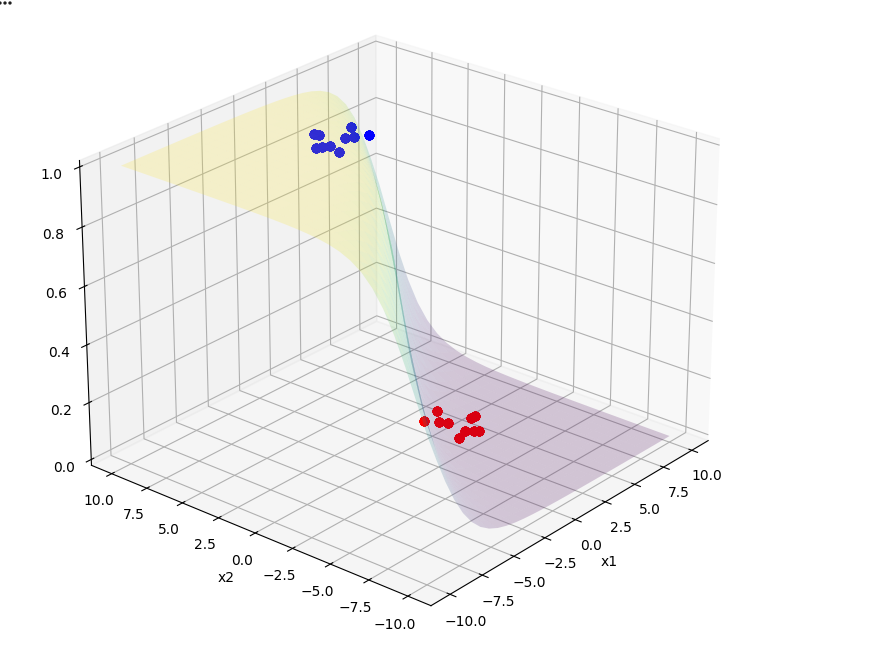

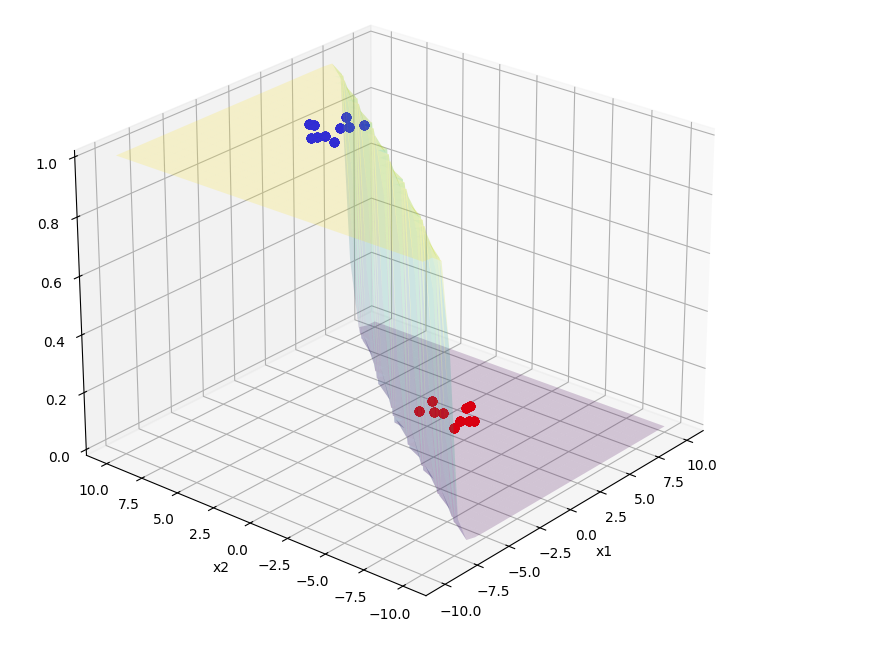

- 뉴런을 늘리면 learning rate를 줄여라. 당연히 뉴런이 늘어났을 때 같은 lr이면 더 큰 변화임.

  - 그래서 파라미터를 100배 키웠으면 lr도 1/10으로 하는게 적당하다. - GPT3 논문

- 마찬가지로 파라미터 수가 늘수록 batch size를 키워야한다. (안정성 증대)

case1 실험:

- 노드가 많을수록 양탄자 경사가 완만하게 내려감. Loss도 덜 내려가고.

- 이 문제의 경우 놀랍게도 뉴런이 2개 밖에 안되도 잘 됨. 꼭 많아야 좋은 것은 아님.

- 층이 깊어져도 항상 좋은게 아님. 층을 늘리면 초반에 학습하는데 오래 걸림. 그래서 epoch를(100을 실패함) 늘려주거나 ADAM을 써야함.

case2 실험:

- 하지만 case2의 데이터 분포의 경우 뉴런이 2개로 충분하지 않음. 어떻게 해도 안됨.

  - 왜냐하면 뉴런 2개를 가지고 어떻게 해도 결국 만들 수 있는 것은 직선의 방정식 뿐임. 결국 `w1x1 + w2x2 + c =0`가 한계, 그리고 이는 결국 일차 방정식임.

  - case2 분포는 선형으로 구별이 안됨.

  - 조금 깊어야지 가능. 이 경우 중간에 시그모이드 하나, 즉 은닉 층이 한층만 되는 plain도 되긴함.

- 너무 깊으면 근데 또 안됨.

  - 모델이 학습할 능력이 있어도 안됨.

  - 왜냐하면 시그모이드를 사용했을 때 gradient vanishing 문제가 일어나기 때문임!

  - 그래서 시그모이드들을 ReLU로 바꾸면 됨!! 뒤로 Loss 전달 가능.

    - 물론 출력층은 그래도 시그모이드를 써야함.



### [Tensorflow Playground- 파라미터 튜닝 연습 사이트](https://playground.tensorflow.org/#activation=relu&batchSize=10&dataset=spiral&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=6,6,6,6,2&seed=0.55779&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false)